![Los Angeles skyline](la_skyline.jpg)

Los Angeles, California 😎. The City of Angels. Tinseltown. The Entertainment Capital of the World! 

Known for its warm weather, palm trees, sprawling coastline, and Hollywood, along with producing some of the most iconic films and songs. However, as with any highly populated city, it isn't always glamorous and there can be a large volume of crime. That's where you can help!

You have been asked to support the Los Angeles Police Department (LAPD) by analyzing crime data to identify patterns in criminal behavior. They plan to use your insights to allocate resources effectively to tackle various crimes in different areas.

## The Data

They have provided you with a single dataset to use. A summary and preview are provided below.

It is a modified version of the original data, which is publicly available from Los Angeles Open Data.

# crimes.csv

| Column     | Description              |
|------------|--------------------------|
| `'DR_NO'` | Division of Records Number: Official file number made up of a 2-digit year, area ID, and 5 digits. |
| `'Date Rptd'` | Date reported - MM/DD/YYYY. |
| `'DATE OCC'` | Date of occurrence - MM/DD/YYYY. |
| `'TIME OCC'` | In 24-hour military time. |
| `'AREA NAME'` | The 21 Geographic Areas or Patrol Divisions are also given a name designation that references a landmark or the surrounding community that it is responsible for. For example, the 77th Street Division is located at the intersection of South Broadway and 77th Street, serving neighborhoods in South Los Angeles. |
| `'Crm Cd Desc'` | Indicates the crime committed. |
| `'Vict Age'` | Victim's age in years. |
| `'Vict Sex'` | Victim's sex: `F`: Female, `M`: Male, `X`: Unknown. |
| `'Vict Descent'` | Victim's descent:<ul><li>`A` - Other Asian</li><li>`B` - Black</li><li>`C` - Chinese</li><li>`D` - Cambodian</li><li>`F` - Filipino</li><li>`G` - Guamanian</li><li>`H` - Hispanic/Latin/Mexican</li><li>`I` - American Indian/Alaskan Native</li><li>`J` - Japanese</li><li>`K` - Korean</li><li>`L` - Laotian</li><li>`O` - Other</li><li>`P` - Pacific Islander</li><li>`S` - Samoan</li><li>`U` - Hawaiian</li><li>`V` - Vietnamese</li><li>`W` - White</li><li>`X` - Unknown</li><li>`Z` - Asian Indian</li> |
| `'Weapon Desc'` | Description of the weapon used (if applicable). |
| `'Status Desc'` | Crime status. |
| `'LOCATION'` | Street address of the crime. |

In [26]:
# Re-run this cell
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
crimes = pd.read_csv("crimes.csv", dtype={"TIME OCC": str})
crimes.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION
0,220314085,2022-07-22,2020-05-12,1110,Southwest,THEFT OF IDENTITY,27,F,B,NaN,Invest Cont,2500 S SYCAMORE AV
1,222013040,2022-08-06,2020-06-04,1620,Olympic,THEFT OF IDENTITY,60,M,H,NaN,Invest Cont,3300 SAN MARINO ST
2,220614831,2022-08-18,2020-08-17,1200,Hollywood,THEFT OF IDENTITY,28,M,H,NaN,Invest Cont,1900 TRANSIENT
3,231207725,2023-02-27,2020-01-27,0635,77th Street,THEFT OF IDENTITY,37,M,H,NaN,Invest Cont,6200 4TH AV
4,220213256,2022-07-14,2020-07-14,0900,Rampart,THEFT OF IDENTITY,79,M,B,NaN,Invest Cont,1200 W 7TH ST


In [27]:
# Start coding here
# Use as many cells as you need

In [28]:
# Check data types and non-null counts
print(crimes.info())

# Count missing values per column
print(crimes.isnull().sum())

# Look for statistical anomalies (like negative ages)
print(crimes.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185715 entries, 0 to 185714
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   DR_NO         185715 non-null  int64 
 1   Date Rptd     185715 non-null  object
 2   DATE OCC      185715 non-null  object
 3   TIME OCC      185715 non-null  object
 4   AREA NAME     185715 non-null  object
 5   Crm Cd Desc   185715 non-null  object
 6   Vict Age      185715 non-null  int64 
 7   Vict Sex      185704 non-null  object
 8   Vict Descent  185705 non-null  object
 9   Weapon Desc   73502 non-null   object
 10  Status Desc   185715 non-null  object
 11  LOCATION      185715 non-null  object
dtypes: int64(2), object(10)
memory usage: 17.0+ MB
None
DR_NO                0
Date Rptd            0
DATE OCC             0
TIME OCC             0
AREA NAME            0
Crm Cd Desc          0
Vict Age             0
Vict Sex            11
Vict Descent        10
Weapon Desc     112213


In [29]:
# Convert date columns to datetime objects
crimes['DATE OCC'] = pd.to_datetime(crimes['DATE OCC'])
crimes['Date Rptd'] = pd.to_datetime(crimes['Date Rptd'])

# TIME OCC is usually military time (e.g., 1110). 
# We pad it to 4 digits and extract the hour.
crimes['hour'] = crimes['TIME OCC'].str.zfill(4).str[:2].astype(int)

In [30]:
# Check how many records have invalid ages (0 or less)
invalid_ages = (crimes['Vict Age'] <= 0).sum()
print(f"Number of invalid age records: {invalid_ages}")

# Action: Replace 0 with NaN or the median age to avoid skewing averages
median_age = crimes[crimes['Vict Age'] > 0]['Vict Age'].median()
crimes.loc[crimes['Vict Age'] <= 0, 'Vict Age'] = median_age

Number of invalid age records: 0


In [31]:
# Define the mapping dictionary based on LAPD documentation
descent_mapping = {
    'A': 'Other Asian', 'B': 'Black', 'C': 'Chinese', 'D': 'Cambodian', 'F': 'Filipino',
    'G': 'Guamanian', 'H': 'Hispanic/Latin/Mexican', 'I': 'American Indian/Alaskan Native',
    'J': 'Japanese', 'K': 'Korean', 'L': 'Laotian', 'P': 'Pacific Islander',
    'S': 'Samoan', 'U': 'Hawaiian', 'V': 'Vietnamese', 'W': 'White', 'X': 'Unknown', 'Z': 'Asian Indian'
}

# Apply the mapping
crimes['Vict Descent'] = crimes['Vict Descent'].map(descent_mapping)

In [32]:
# Remove duplicate records based on the unique Division Record Number (DR_NO)
crimes = crimes.drop_duplicates(subset=['DR_NO'])

# Drop columns that are mostly empty (Crm Cd 2, 3, 4 often have 99% missing data)
cols_to_drop = ['Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'Cross Street']
crimes.drop(columns=cols_to_drop, inplace=True, errors='ignore')

In [33]:
# Standardize text: remove extra spaces and ensure consistent casing
crimes['AREA NAME'] = crimes['AREA NAME'].str.strip().str.title()
crimes['Crm Cd Desc'] = crimes['Crm Cd Desc'].str.strip().str.capitalize()

In [34]:
# 1. Check Data Types to ensure conversion to datetime was successful
print("--- Data Types Check ---")
print(crimes[['Date Rptd', 'DATE OCC', 'hour']].dtypes)

# 2. Check a random sample to see if 'hour' matches 'TIME OCC'
print("\n--- Random Sample Check ---")
print(crimes[['TIME OCC', 'hour']].sample(5))

# 3. Validation: Ensure hour values are within the logical range (0-23)
print("\n--- Hour Range Check ---")
print(f"Min Hour: {crimes['hour'].min()}, Max Hour: {crimes['hour'].max()}")

--- Data Types Check ---
Date Rptd    datetime64[ns]
DATE OCC     datetime64[ns]
hour                  int64
dtype: object

--- Random Sample Check ---
       TIME OCC  hour
54248      1405    14
88084      1404    14
79892      0130     1
67115      2330    23
177614     1150    11

--- Hour Range Check ---
Min Hour: 0, Max Hour: 23


In [35]:
# 1. Fill missing 'Weapon Desc' with 'Unknown'
# It's likely no weapon was used or it wasn't recorded.
crimes['Weapon Desc'] = crimes['Weapon Desc'].fillna('Unknown')

# 2. Fill 'Vict Sex' and 'Vict Descent' with 'X' (Unknown)
# This prevents these rows from being ignored during demographic analysis.
crimes['Vict Sex'] = crimes['Vict Sex'].fillna('X')
crimes['Vict Descent'] = crimes['Vict Descent'].fillna('X')

# Verify that these specific nulls are gone
print(crimes[['Weapon Desc', 'Vict Sex', 'Vict Descent']].isnull().sum())

Weapon Desc     0
Vict Sex        0
Vict Descent    0
dtype: int64


In [36]:
# 1. Identify how many records have an age of 0 or less
print(f"Invalid age records: {(crimes['Vict Age'] <= 0).sum()}")

# 2. Strategy: Replace invalid ages with the Median age
# We use Median instead of Mean because it's less sensitive to outliers.
median_age = crimes[crimes['Vict Age'] > 0]['Vict Age'].median()
crimes.loc[crimes['Vict Age'] <= 0, 'Vict Age'] = median_age

# 3. Final Check: Ensure minimum age is now logical
print(f"New Minimum Age: {crimes['Vict Age'].min()}")

Invalid age records: 0
New Minimum Age: 2


In [37]:
# Define the mapping based on the instructions in your notebook image
descent_map = {
    'A': 'Other Asian', 'B': 'Black', 'C': 'Chinese', 'D': 'Cambodian', 'F': 'Filipino',
    'G': 'Guamanian', 'H': 'Hispanic/Latin/Mexican', 'I': 'American Indian/Alaskan Native',
    'J': 'Japanese', 'K': 'Korean', 'L': 'Laotian', 'P': 'Pacific Islander',
    'S': 'Samoan', 'U': 'Hawaiian', 'V': 'Vietnamese', 'W': 'White', 'X': 'Unknown', 'Z': 'Asian Indian'
}

crimes['Vict Descent'] = crimes['Vict Descent'].replace(descent_map)

The hour with the highest number of crimes is: 12:00


C:\Users\marie\AppData\Local\Temp\ipykernel_33116\2990837491.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=crimes, x='hour', palette='magma')


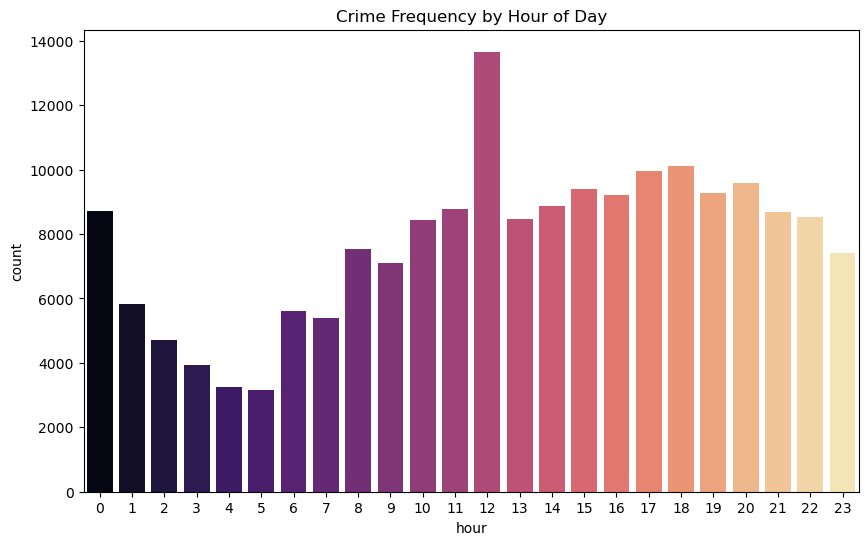

In [38]:
# Count the number of crimes for each hour
peak_crime_hour = crimes['hour'].value_counts().idxmax()
print(f"The hour with the highest number of crimes is: {peak_crime_hour}:00")

# Visualization: Plot crimes by hour
plt.figure(figsize=(10,6))
sns.countplot(data=crimes, x='hour', palette='magma')
plt.title('Crime Frequency by Hour of Day')
plt.show()

Top 10 Dangerous Areas:
AREA NAME
Central        14944
Southwest      11945
77Th Street    11739
Pacific         9923
Hollywood       9762
Southeast       9571
Olympic         9414
Newton          9152
Van Nuys        8621
N Hollywood     8502
Name: count, dtype: int64


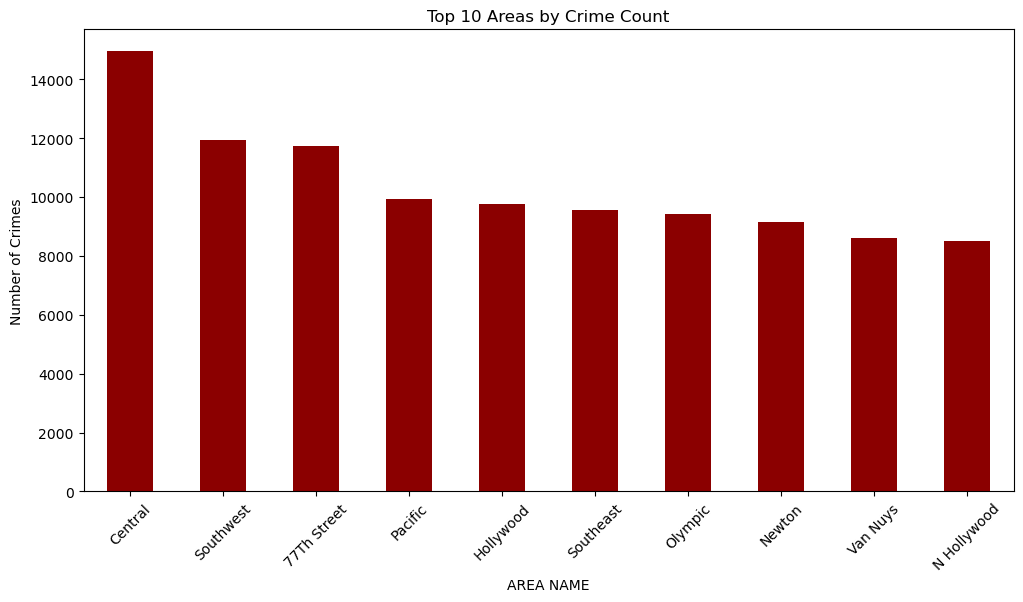

In [39]:
# Find the top 10 areas with the most crimes
top_10_areas = crimes['AREA NAME'].value_counts().head(10)
print("Top 10 Dangerous Areas:")
print(top_10_areas)

# Plotting the top 10 areas
plt.figure(figsize=(12,6))
top_10_areas.plot(kind='bar', color='darkred')
plt.title('Top 10 Areas by Crime Count')
plt.ylabel('Number of Crimes')
plt.xticks(rotation=45)
plt.show()

In [40]:
# Get the top 5 most common crimes
common_crimes = crimes['Crm Cd Desc'].value_counts().head(5)
print("Top 5 Crime Types:")
print(common_crimes)

Top 5 Crime Types:
Crm Cd Desc
Theft of identity                                 22670
Battery - simple assault                          19694
Burglary from vehicle                             13799
Assault with deadly weapon, aggravated assault    13215
Intimate partner - simple assault                 11981
Name: count, dtype: int64


In [41]:
# Create age bins (e.g., 0-17, 18-25, 26-34, 35-44, 45-54, 55-64, 65+)
age_bins = [0, 17, 25, 34, 44, 54, 64, np.inf]
age_labels = ['0-17', '18-25', '26-34', '35-44', '45-54', '55-64', '65+']

crimes['Age Group'] = pd.cut(crimes['Vict Age'], bins=age_bins, labels=age_labels)

# See which age group is most victimized
print(crimes['Age Group'].value_counts())

Age Group
26-34    47470
35-44    42157
45-54    28353
18-25    28291
55-64    20169
65+      14747
0-17      4528
Name: count, dtype: int64


C:\Users\marie\AppData\Local\Temp\ipykernel_33116\2622065982.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=victim_descent_counts.index, y=victim_descent_counts.values, palette='viridis')


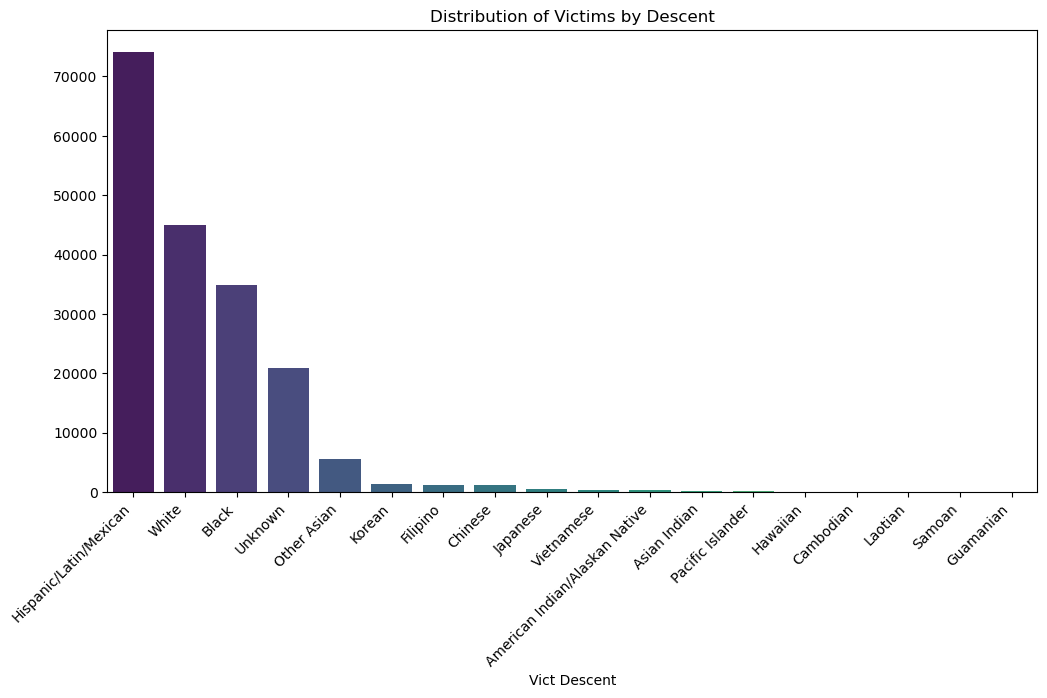

In [42]:
plt.figure(figsize=(12, 6))
sns.barplot(x=victim_descent_counts.index, y=victim_descent_counts.values, palette='viridis')

# Rotate the labels by 45 degrees
plt.xticks(rotation=45, ha='right') 

plt.title('Distribution of Victims by Descent')
plt.show()

C:\Users\marie\AppData\Local\Temp\ipykernel_33116\1619024653.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=crimes_by_day.index, y=crimes_by_day.values, palette='coolwarm')


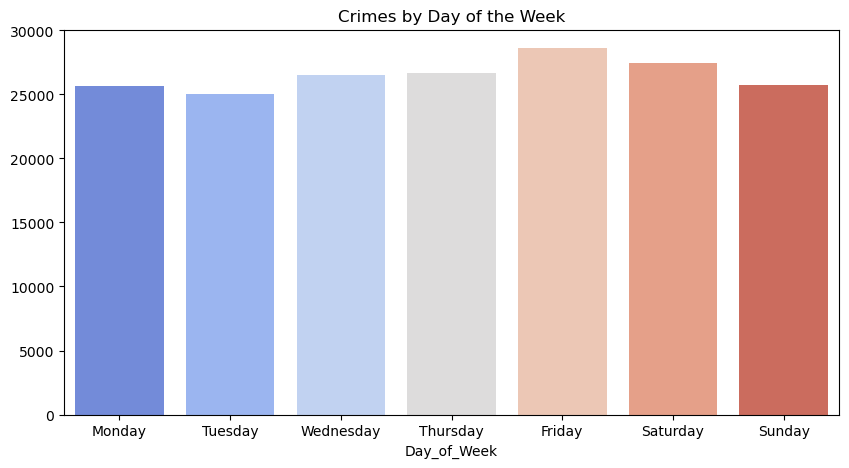

In [43]:
# Create a Day of Week column
crimes['Day_of_Week'] = crimes['DATE OCC'].dt.day_name()

# Order the days correctly
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
crimes_by_day = crimes['Day_of_Week'].value_counts().reindex(days_order)

# Plotting
plt.figure(figsize=(10, 5))
sns.barplot(x=crimes_by_day.index, y=crimes_by_day.values, palette='coolwarm')
plt.title('Crimes by Day of the Week')
plt.show()

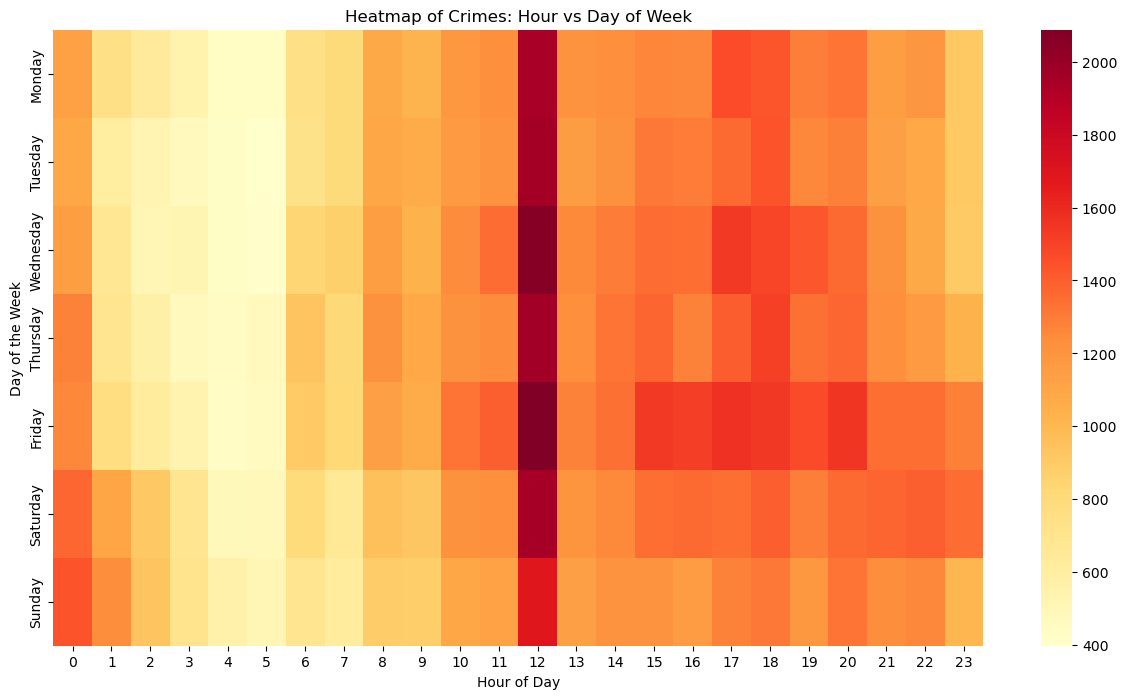

In [44]:
# Create a pivot table for the heatmap
heatmap_data = crimes.groupby(['Day_of_Week', 'hour']).size().unstack().reindex(days_order)

# Plotting the heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=False)
plt.title('Heatmap of Crimes: Hour vs Day of Week')
plt.xlabel('Hour of Day')
plt.ylabel('Day of the Week')
plt.show()

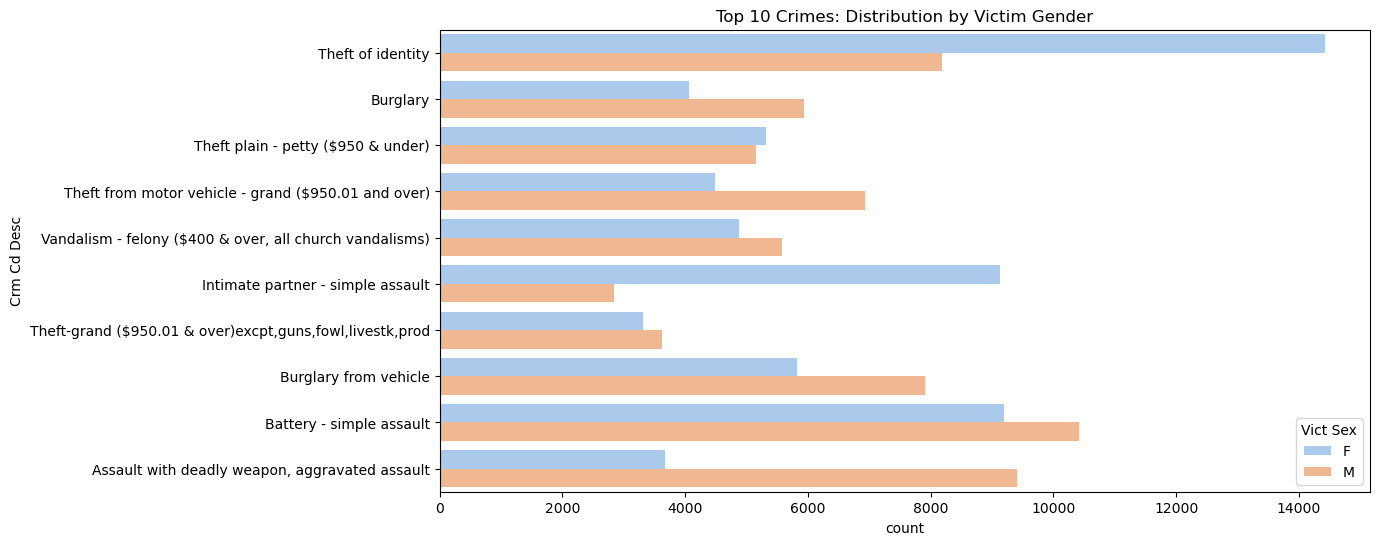

In [45]:
# Get the top 10 crime types
top_crimes = crimes['Crm Cd Desc'].value_counts().head(10).index

# Filter the dataframe for these top crimes and valid genders (M/F)
gender_crime = crimes[(crimes['Crm Cd Desc'].isin(top_crimes)) & (crimes['Vict Sex'].isin(['M', 'F']))]

# Plotting
plt.figure(figsize=(12, 6))
sns.countplot(data=gender_crime, y='Crm Cd Desc', hue='Vict Sex', palette='pastel')
plt.title('Top 10 Crimes: Distribution by Victim Gender')
plt.show()